# Learning assignment 

Study topics on OSMnx and data visualization

In [4]:
# importing library

import osmnx as ox

In [5]:
# getting the location 
place = "Novi Sad, Serbia"

In [6]:
# searching for specific features

tags = {"building": True, "landuse": "residential"}

In [7]:
# retrieving features

gdf = ox.features_from_place(place, tags)

In [8]:
gdf.head()

geometry       amenity    building  \
element id                                                                 
node    7410289629    POINT (19.79283 45.2554)  events_venue  commercial   
        12892377431  POINT (19.83422 45.28304)           NaN        roof   
        13615116049   POINT (19.8473 45.25156)           NaN         yes   
        13758940033  POINT (19.83243 45.25196)           NaN  apartments   
        13863916284   POINT (19.8342 45.28306)           NaN        roof   

                             name       name:en       name:sr  name:sr-Latn  \
element id                                                                    
node    7410289629   Exclusive NS  Exclusive NS  Ексклузив НС  Ekskluziv NS   
        12892377431           NaN           NaN           NaN           NaN   
        13615116049       Bačka S           NaN       Бачка С       Bačka S   
        13758940033           NaN           NaN           NaN           NaN   
        13863916284           NaN           NaN           NaN           NaN   

                                      website addr:housenumber   addr:street  \
element id                                                                     
node    7410289629   https://exclusivens.com/              NaN           NaN   
        12892377431                       NaN              NaN           NaN   
        13615116049                       NaN                1  Стражиловска   
        13758940033                       NaN                2      Таковска   
        13863916284                       NaN              NaN           NaN   

                     ... blood:plasma blood:platelets blood:stemcells  \
element id           ...                                                
node    7410289629   ...          NaN             NaN             NaN   
        12892377431  ...          NaN             NaN             NaN   
        13615116049  ...          NaN             NaN             NaN   
        13758940033  ...          NaN             NaN             NaN   
        13863916284  ...          NaN             NaN             NaN   

                    blood:whole donation:compensation name:rsk name:es  \
element id                                                               
node    7410289629          NaN                   NaN      NaN     NaN   
        12892377431         NaN                   NaN      NaN     NaN   
        13615116049         NaN                   NaN      NaN     NaN   
        13758940033         NaN                   NaN      NaN     NaN   
        13863916284         NaN                   NaN      NaN     NaN   

                    name:zh alt_name:sr-Latn alt_name:en  
element id                                                
node    7410289629      NaN              NaN         NaN  
        12892377431     NaN              NaN         NaN  
        13615116049     NaN              NaN         NaN  
        13758940033     NaN              NaN         NaN  
        13863916284     NaN              NaN         NaN  

[5 rows x 275 columns]

<Axes: >

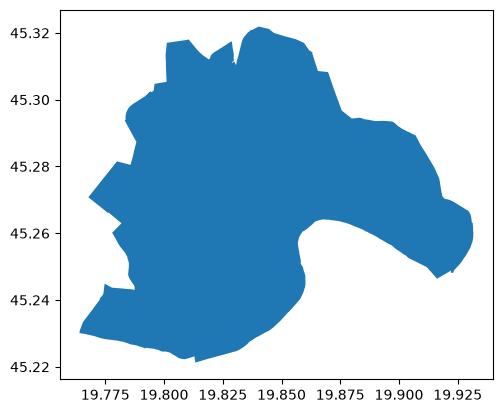

In [9]:
# getting boundary of the location
boundary = ox.geocode_to_gdf(place)
boundary.plot()

In [10]:
import networkx as nx

In [11]:
ox.settings.log_console = True
ox.__version__

'2.1.0'

In [24]:
G = ox.graph.graph_from_place(place, network_type="all")
fig, ax = ox.plot.plot_graph(G)

ConnectionError: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by NewConnectionError("HTTPSConnection(host='overpass-api.de', port=443): Failed to establish a new connection: [Errno 111] Connection refused"))

In [ ]:
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m

In [ ]:
ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

> OSMnx dont see a map, it sees the data as is:

{
    "name": "NAME",
    "amenity": "type",
    "geometry": ....
}

### Workflow

OSM => Overpass API => GeoDataFrame(GDF) => Analisys => Visualization


# OSMnx

It's a translator that convers tags and query that OpenStreetMap undestand and then download results.

In [ ]:
gdf = ox.geocoder.geocode_to_gdf("Las Piñas, Philippines")

In [ ]:
gdf.plot()

In [ ]:
gdf = gdf.to_crs(gdf.estimate_utm_crs())
gdf["area_m2"] = gdf.area

In [ ]:
places = [
    "Novi Sad, Serbia",
    "Las Piñas, Philippines",
]

gdf = ox.geocoder.geocode_to_gdf(places)

In [ ]:
gdf.head()

In [ ]:
ph = "Las Piñas, Philippines"

In [ ]:
graph = ox.graph_from_place(ph, simplify=True, network_type= "all")

In [ ]:
type(graph)

In [ ]:
fig, ax = ox.plot_graph(graph, edge_linewidth=0.5, node_size=10, node_color="#66cc66")